In [23]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("done")

done


In [26]:
df = pd.read_csv('../data/diabetes.csv')
print("Shape:", df.shape)
print("\nOutcome distribution:")
print(df['Outcome'].value_counts())
df.head()

Shape: (768, 9)

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [28]:
print("Missing values:\n", df.isnull().sum())
print("\nOutcome distribution:\n", df['Outcome'].value_counts())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


## great no missing values lol

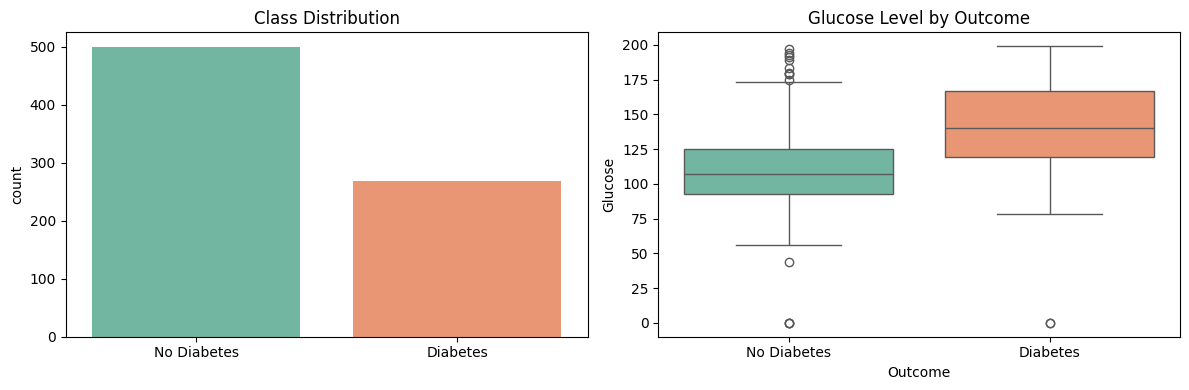

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class balance
sns.countplot(x='Outcome', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[0].set_xlabel('')

# glucose by outcome
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Glucose Level by Outcome')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

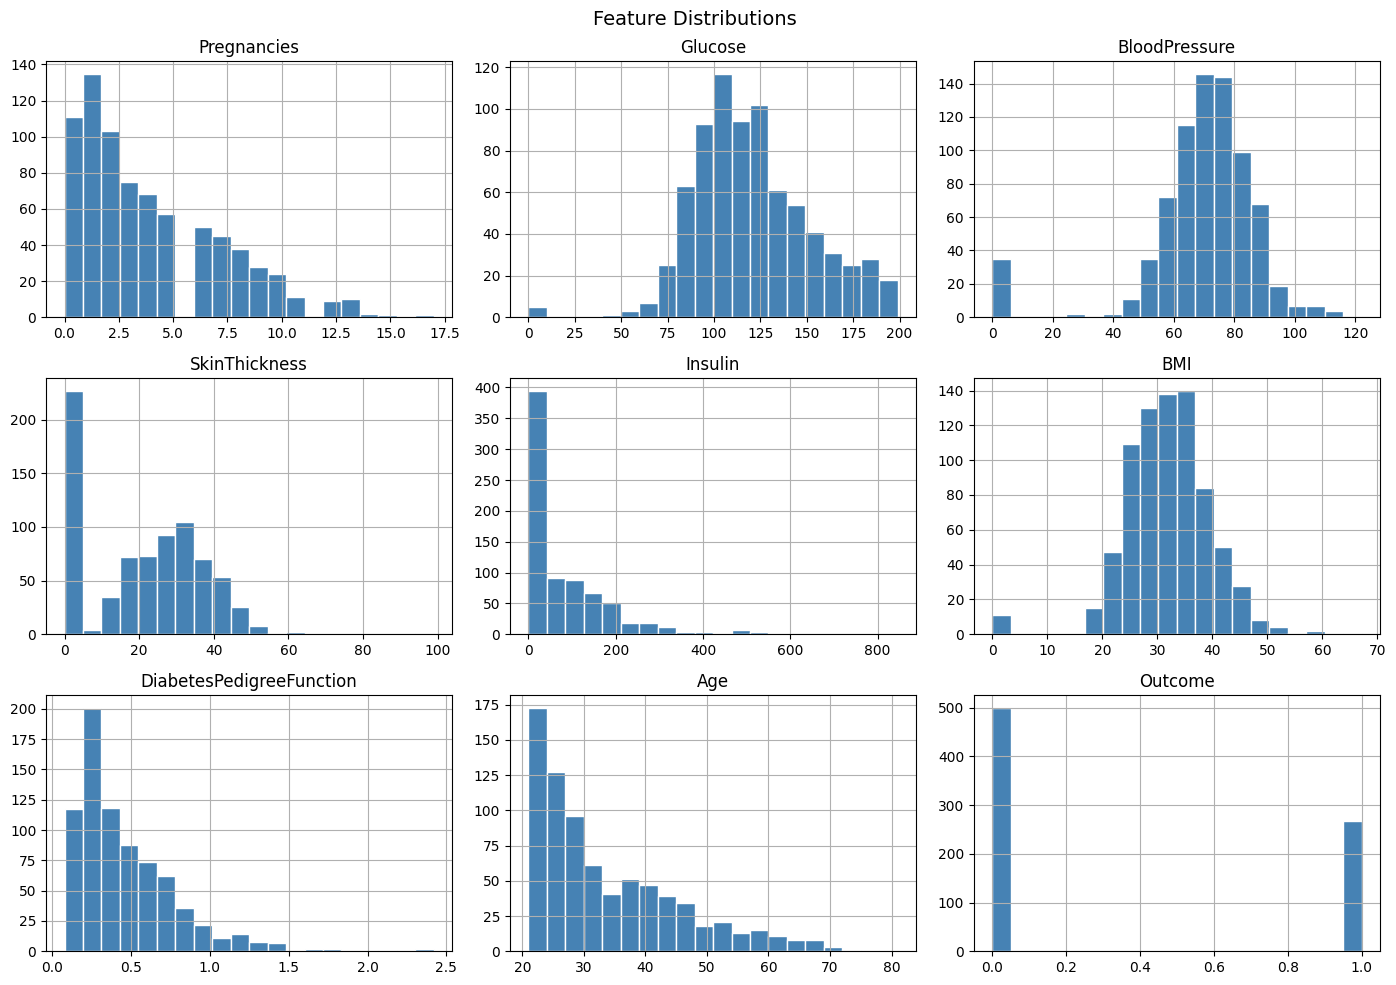

In [31]:
df.hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

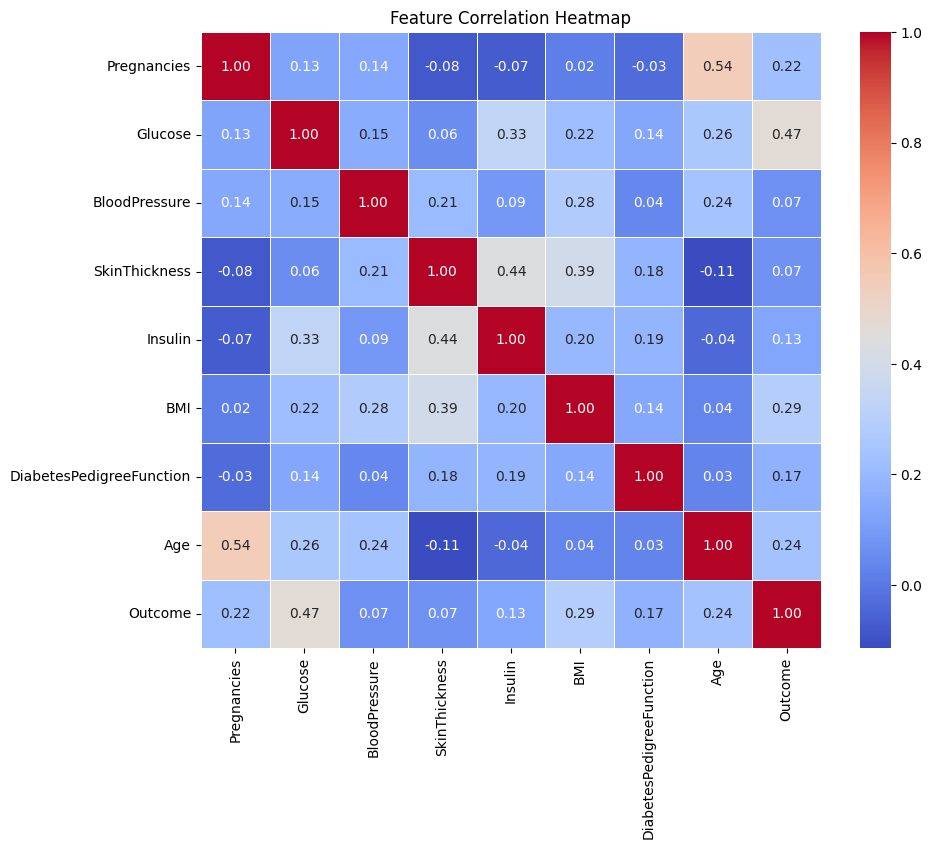

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [36]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    median_val = df[col].median()
    df[col] = df[col].replace(0, median_val)
    print(f"{col}: replaced zeros with median ({median_val:.1f})")

print("\nData cleaned")

Glucose: replaced zeros with median (117.0)
BloodPressure: replaced zeros with median (72.0)
SkinThickness: replaced zeros with median (23.0)
Insulin: replaced zeros with median (30.5)
BMI: replaced zeros with median (32.0)

Data cleaned


### glucose being the most imp attribute

In [37]:
# feature eng, as randomforest and gbm both were upto 77% accuracy
df['glucose_bmi']           = df['Glucose'] * df['BMI']
df['age_bmi']               = df['Age'] * df['BMI']
df['glucose_age']           = df['Glucose'] * df['Age']
df['insulin_glucose_ratio'] = df['Insulin'] / (df['Glucose'] + 1)

print("New shape after feature engineering:", df.shape)
print("New features added:")
print("  glucose_bmi, age_bmi, glucose_age, insulin_glucose_ratio")
df.head()

New shape after feature engineering: (768, 13)
New features added:
  glucose_bmi, age_bmi, glucose_age, insulin_glucose_ratio


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,glucose_bmi,age_bmi,glucose_age,insulin_glucose_ratio
0,6,148,72,35,30.5,33.6,0.627,50,1,4972.8,1680.0,7400,0.204698
1,1,85,66,29,30.5,26.6,0.351,31,0,2261.0,824.6,2635,0.354651
2,8,183,64,23,30.5,23.3,0.672,32,1,4263.9,745.6,5856,0.165761
3,1,89,66,23,94.0,28.1,0.167,21,0,2500.9,590.1,1869,1.044444
4,0,137,40,35,168.0,43.1,2.288,33,1,5904.7,1422.3,4521,1.217391


In [38]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features:", X.shape)
print("Target:  ", y.shape)
print("\nAll feature columns:")
print(list(X.columns))

Features: (768, 12)
Target:   (768,)

All feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'glucose_bmi', 'age_bmi', 'glucose_age', 'insulin_glucose_ratio']


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("features scaled")
print("Mean after scaling (should be ~0):", X_scaled.mean().round(2).values[:4])
print("Std after scaling  (should be ~1):", X_scaled.std().round(2).values[:4])

features scaled
Mean after scaling (should be ~0): [-0.  0.  0. -0.]
Std after scaling  (should be ~1): [1. 1. 1. 1.]


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nTrain outcome distribution:\n{y_train.value_counts()}")

Training samples: 614
Testing samples:  154

Train outcome distribution:
Outcome
0    400
1    214
Name: count, dtype: int64


In [43]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After SMOTE: ", dict(pd.Series(y_train_sm).value_counts()))
print("\nclass balance fixed")

Before SMOTE: {0: np.int64(400), 1: np.int64(214)}
After SMOTE:  {0: np.int64(400), 1: np.int64(400)}

class balance fixed


In [45]:

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)

print("\nGrid search complete")
print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Grid search complete
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 score: 0.8339


### well this is better than prev random forest results

In [46]:
best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy*100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test, predictions,
      target_names=['No Diabetes', 'Diabetes']))

Accuracy: 75.97%

Detailed Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.76      0.80       100
    Diabetes       0.63      0.76      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154



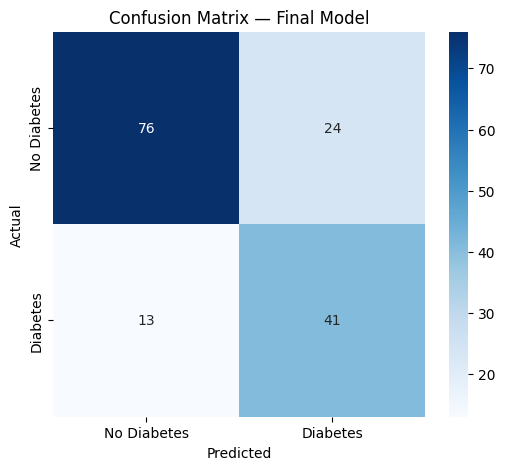

In [47]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## umm 2% accuracy raise yay

### using gradient classifier this time

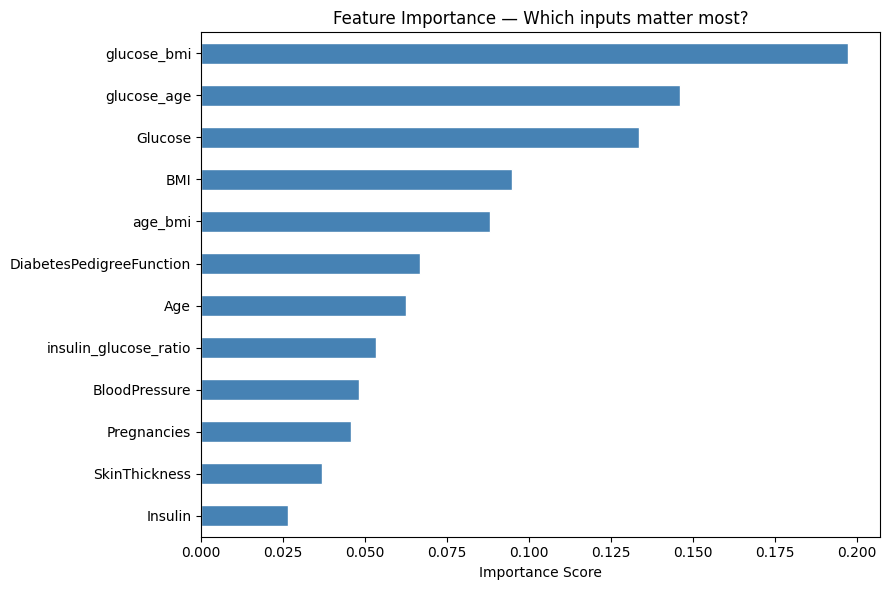

In [48]:
importances = pd.Series(best_model.feature_importances_,
                        index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(9, 6), color='steelblue', edgecolor='white')
plt.title('Feature Importance — Which inputs matter most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [50]:
cv_scores = cross_val_score(best_model, X_scaled, y, cv=10, scoring='accuracy')

print("10-Fold Cross Validation Results:")
print(f"  Scores: {cv_scores.round(3)}")
print(f"  Mean:   {cv_scores.mean()*100:.2f}%")
print(f"  Std:    {cv_scores.std()*100:.2f}%")
print(f"\nreliable accuracy.")

10-Fold Cross Validation Results:
  Scores: [0.74  0.766 0.727 0.688 0.714 0.818 0.831 0.805 0.724 0.789]
  Mean:   76.04%
  Std:    4.63%

reliable accuracy.


Logistic Regression            → 70.13%
Random Forest (tuned)          → 75.97%
Gradient Boosting              → 76.62%
SVM                            → 74.68%


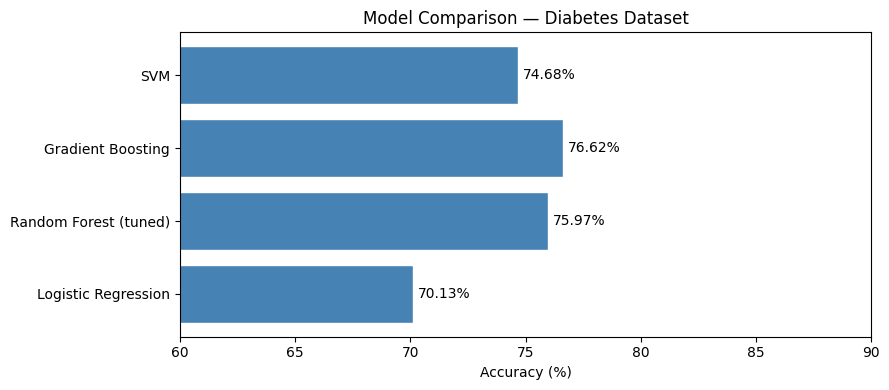

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest (tuned)": best_model,
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM":                 SVC(kernel='rbf', class_weight='balanced')
}

results = {}
for name, m in models.items():
    if name != "Random Forest (tuned)":
        m.fit(X_train_sm, y_train_sm)
    acc = accuracy_score(y_test, m.predict(X_test))
    results[name] = round(acc * 100, 2)
    print(f"{name:30s} → {acc*100:.2f}%")

plt.figure(figsize=(9, 4))
plt.barh(list(results.keys()), list(results.values()),
         color='steelblue', edgecolor='white')
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison — Diabetes Dataset')
plt.xlim(60, 90)
for i, v in enumerate(results.values()):
    plt.text(v + 0.2, i, f"{v}%", va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [53]:
os.makedirs('../models', exist_ok=True)

# g boosting with the best result
final_model = models["Gradient Boosting"]

joblib.dump(final_model, '../models/diabetes_model.pkl')
joblib.dump(scaler,      '../models/diabetes_scaler.pkl')

print("Model saved")
print("Scaler saved ")
print(f"Final model: Gradient Boosting — 76.62%")
print(f"Features used: {list(X.columns)}")

Model saved
Scaler saved 
Final model: Gradient Boosting — 76.62%
Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'glucose_bmi', 'age_bmi', 'glucose_age', 'insulin_glucose_ratio']
